#**1. Reflection**
Reflection은 에이전트가 스스로 결과를 평가·비판 한 뒤 그 피드백을 상태(state)에 기록하고, 필요하면 수정 루프로 되돌아가 답을 개선하는 설계 패턴입니다. 보통 “작성 노드(답 생성) → 리플렉션 노드(자기평가) → 라우팅(조건부 엣지)”로 구성되며, 리플렉션 노드는 품질 기준(예: 정확성, 근거, 형식)을 점수·코멘트(score, critique)로 남깁니다. 라우터는 이 정보를 읽어 임계값 미달이면 작성 노드로 되감기, 충족하면 종료 노드로 이동합니다. 무한 루프를 막기 위해 max_iters 같은 반복 한도를 두며, 툴 호출과는 별개로 LLM의 자기검토 능력을 활용해 코드 생성, 질의응답, 체인드 리저닝 등의 정확도·일관성을 높이는 데 쓰입니다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fet5eoq%2FbtsQtfTBoz7%2FAAAAAAAAAAAAAAAAAAAAAM6C44vgBF-5pX8AStDskIMKM2c-gg9io9wsDgxh0NT0%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3D5r2AoFcs9RsXoictxR7M800sVgA%253D'>

- 가사 생성기: 사용자 요청을 받아 5단락 가사를 생성
- 가사 평가기
    - 만들어진 가사를 읽고 잘된 점
    - 아쉬운 점
    - 수정 지시사항 등을 만듦
- 가사 수정기: 평가 내용을 다시 생성기에게 주고, 이전 가사를 더 좋게 고쳐서 새 버전을 만듦

> 단순히 한 번만 생성하는 것이 아니라, 한 번 생성한 결과를 다시 비판하고 개선하는 구조

In [1]:
import getpass
import os

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

OPENAI_API_KEY: ··········


In [2]:
!pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 13.1 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.19
    Uninstalling langchain-core-1.2.19:
      Successfully uninstalled langchain-core-1.2.19


In [5]:
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI

# ChatPromptTemplate: 채팅형 프롬프트를 만드는 툴. system, human, ai 같은 메시지 구조를 쉽게 만들 수 있음
# from_messages: 메시지 목록으로 프롬프트를 구성
# MessagesPlaceholder: 나중에 실제 대화 메시지들이 들어갈 자리
prompt = ChatPromptTemplate.from_messages(
    [
        ("system",
            "당신은 5단락 노래 가사를 작성하는 작사 도우미입니다. "
            "사용자의 요청에 맞게 주제, 분위기, 감정을 반영한 가사를 작성하세요. "
            "좋은 가사는 감정이 자연스럽게 이어지고, 표현이 구체적이며, 전체 흐름이 일관되어야 합니다. "
            "사용자가 피드백을 제공하면, 이전 결과를 그대로 반복하지 말고 "
            "지적된 부분이 눈에 띄게 개선된 수정본을 작성하세요. "
            "이때 잘된 표현과 핵심 주제는 유지하고, 감정 표현, 문장 자연스러움, 이미지 표현을 더 좋게 다듬으세요. "
            "반드시 5단락으로 작성하고, 각 단락은 명확히 구분하세요."),
        MessagesPlaceholder(variable_name='messages')
    ]
)

llm = ChatOpenAI(model="gpt-5.4-2026-03-05")
generate = prompt | llm

In [6]:
draft_lyrics = ""

request = HumanMessage(content="이별에 대한 가사를 작성해주세요.")

for chunk in generate.stream({"messages": [request]}):
    if chunk.content:
        print(chunk.content, end='')
        draft_lyrics += chunk.content

print("\n\n[초안 가사]")
print(draft_lyrics)

1.
문득 멈춘 골목 끝에 네가 서 있을 것 같아  
익숙한 발걸음 소리에 자꾸 뒤를 돌아봐  
함께 걷던 계절들은 아직 여기 남아 있는데  
너 없는 이 거리는 너무 조용해서 아파

2.
아무렇지 않은 척 웃어보려 해도  
작은 기억 하나에도 마음이 무너져  
네가 두고 간 말들이 귓가에 맴돌아서  
하루가 저물수록 더 선명해지는 너야

3.
우린 서로의 세상이 될 줄 알았었는데  
사랑은 왜 끝내 손끝에서 흩어질까  
잡으려 할수록 멀어지는 바람처럼  
너는 내 마음 깊은 곳에 상처로 남아

4.
이별은 생각보다 더 천천히 번져와  
괜찮아졌다고 믿던 밤에도 널 불러  
지우려 애써봐도 더 짙어지는 얼굴  
사랑했던 만큼 아픈 게 맞는 거겠지

5.
이제는 너를 보내야 한다는 걸 알아  
눈물로 붙잡아도 돌아오지 않을 테니  
우리의 마지막을 가슴에 접어 두고  
언젠가 웃으며 추억할 날을 기다릴게

[초안 가사]
1.
문득 멈춘 골목 끝에 네가 서 있을 것 같아  
익숙한 발걸음 소리에 자꾸 뒤를 돌아봐  
함께 걷던 계절들은 아직 여기 남아 있는데  
너 없는 이 거리는 너무 조용해서 아파

2.
아무렇지 않은 척 웃어보려 해도  
작은 기억 하나에도 마음이 무너져  
네가 두고 간 말들이 귓가에 맴돌아서  
하루가 저물수록 더 선명해지는 너야

3.
우린 서로의 세상이 될 줄 알았었는데  
사랑은 왜 끝내 손끝에서 흩어질까  
잡으려 할수록 멀어지는 바람처럼  
너는 내 마음 깊은 곳에 상처로 남아

4.
이별은 생각보다 더 천천히 번져와  
괜찮아졌다고 믿던 밤에도 널 불러  
지우려 애써봐도 더 짙어지는 얼굴  
사랑했던 만큼 아픈 게 맞는 거겠지

5.
이제는 너를 보내야 한다는 걸 알아  
눈물로 붙잡아도 돌아오지 않을 테니  
우리의 마지막을 가슴에 접어 두고  
언젠가 웃으며 추억할 날을 기다릴게


In [7]:
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "당신은 노래 가사를 평가하고 개선 방향을 제안하는 작사 코치입니다. "
            "사용자가 제출한 가사를 읽고 주제의 일관성, 감정의 깊이, 표현의 구체성, "
            "문체의 자연스러움, 단락 간 흐름을 기준으로 평가하세요. "
            "응답은 반드시 다음 세 부분으로 작성하세요. "
            "1. 잘된 점 "
            "2. 아쉬운 점 "
            "3. 수정 지시사항 "
            "수정 지시사항은 다음 작사 단계에서 바로 반영할 수 있을 만큼 구체적으로 작성하세요.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)
reflect = reflection_prompt | llm

In [8]:
reflection_feedback = ""
for chunk in reflect.stream({
    "messages": [
        request,
        AIMessage(content=draft_lyrics)
    ]
}):
    if chunk.content:
        print(chunk.content, end='')
        reflection_feedback += chunk.content
print("\n\n[피드백]")
print(reflection_feedback)

1. 잘된 점  
- 이별의 정서를 익숙하고 안정적으로 담아냈습니다.  
- “익숙한 발걸음 소리”, “함께 걷던 계절”, “너 없는 거리” 같은 표현은 이별 후 공허함을 자연스럽게 떠올리게 합니다.  
- 전체적으로 감정선이 무너지지 않고, 그리움 → 상처 → 체념으로 이어지는 흐름이 비교적 매끄럽습니다.  
- 후렴처럼 활용할 수 있는 문장들이 많아 가사 형태로 확장하기 좋습니다. 예를 들어 “사랑했던 만큼 아픈 게 맞는 거겠지”는 감정의 핵심을 잘 압축한 문장입니다.  

2. 아쉬운 점  
- 표현이 전반적으로 익숙하고 보편적이라, 이 가사만의 개성이 강하게 드러나진 않습니다.  
- “조용해서 아파”, “마음이 무너져”, “상처로 남아”, “더 짙어지는 얼굴” 등은 많이 쓰이는 이별 표현이라 신선도가 다소 약합니다.  
- 화자와 상대의 구체적인 관계나 이별의 장면이 드러나지 않아 감정은 공감되지만 인상적인 이미지가 조금 부족합니다.  
- 각 연이 비슷한 온도의 슬픔을 유지하고 있어, 어느 한 지점에서 감정이 폭발하거나 확 꺾이는 인상적인 변곡점이 약합니다.  
- 문체는 자연스럽지만, 몇몇 줄은 추상적인 감정 설명에 머물러 있어 듣는 사람이 장면을 선명하게 그리기엔 다소 아쉽습니다.  

3. 수정 지시사항  
- 다음 버전에서는 “슬프다, 아프다, 무너진다” 같은 직접 감정어를 줄이고, 대신 장면으로 감정을 보여주세요.  
  - 예: “너 없는 이 거리는 너무 조용해서 아파” → “횡단보도 앞에 서도 네 쪽으로 고개가 먼저 돌아가”  
- 둘만의 구체적인 기억을 최소 2개 넣어주세요.  
  - 함께 듣던 노래, 자주 가던 카페, 헤어진 계절, 마지막 통화 시간 같은 디테일이 있으면 가사가 훨씬 살아납니다.  
- 1절은 “이별 후 일상에서 느끼는 빈자리”, 2절은 “헤어지던 순간의 기억”, 후렴은 “아직 못 놓는 마음”으로 역할을 분명히 나눠보세요.  
- 후렴에는 반복 가능한 핵심 문장을 하나 정하세요.  
  - 예: “너를 지우는 일은 

In [9]:
revised_lyrics = ""
revision_request = HumanMessage(
    content=(
        "아래 피드백을 반드시 반영하여 이전 가사를 수정해주세요. "
        "원문을 그대로 반복하지 말고, 표현과 감정을 더 풍부하게 개선해주세요.\n\n"
        f"{reflection_feedback}"
    )
)

for chunk in generate.stream({
    "messages": [
        request,
        AIMessage(content=draft_lyrics),
        revision_request
    ]
}):
    if chunk.content:
        print(chunk.content, end='')
        revised_lyrics += chunk.content

print("\n\n[수정본 가사]")
print(revised_lyrics)

1.
아침 여섯 시, 알람보다 먼저 눈이 떠지면  
버릇처럼 재생 목록 첫 칸의 네 노래를 넘겨  
창가에 놓인 두 개의 머그 중 하나는 아직도 금이 간 채로  
나는 하나만 씻어 말리고, 하나는 그대로 둔 채 출근을 나서  
횡단보도 앞에 서면 아직도 네가 서 있던 오른쪽부터 보게 돼

2.
우리가 끝난 건 비가 오던 십일월, 역 앞 작은 카페였지  
식어버린 라테 위로 네 손가락이 컵 가장자리만 천천히 돌았고  
“잘 지내”보다 먼저 긴 침묵이 테이블 위에 내려앉았어  
오후 9시 17분, 마지막 통화 목록에 찍힌 네 이름 아래로  
나는 끝내 묻지 못한 말들을 목도리처럼 몇 번이고 감았지

3.
너를 지우는 일은 나를 비우는 일이야  
네가 앉던 자리의 공기까지 비워내야 하니까  
너를 지우는 일은 나를 비우는 일이야  
함께 듣던 노래의 후렴이 나오는 순간마다  
나는 아무 일 없던 사람처럼 창밖만 오래 보게 돼

4.
친구들 틈에 섞여 웃다가도, 골목 끝 붕어빵 냄새가 스치면  
작년 겨울 네 입김 위로 장난처럼 그렸던 하트가 떠올라  
별일 아닌 하루인 척, 잘 접어 둔 얼굴로 걷고 있었는데  
편의점 냉장고 문에 비친 내 어깨가 이상하게 비어 보여서  
그제야 알았어, 잊는 건 멀어지는 게 아니라 자꾸 선명해지는 거란 걸

5.
그래도 이제는 네 쪽으로 기울던 습관을 조금씩 세워 둘게  
자주 가던 카페 창가 자리에 앉아도 다른 메뉴를 고를 거야  
마지막 인사는 겨울 코트 주머니 안쪽에 넣어 둔 채로  
계절이 몇 번 더 바뀌면 영수증 글씨처럼 흐려지겠지  
그때는 네 이름을 불지 않고도, 첫눈을 끝까지 바라볼 수 있기를

[수정본 가사]
1.
아침 여섯 시, 알람보다 먼저 눈이 떠지면  
버릇처럼 재생 목록 첫 칸의 네 노래를 넘겨  
창가에 놓인 두 개의 머그 중 하나는 아직도 금이 간 채로  
나는 하나만 씻어 말리고, 하나는 그대로 둔 채 출근을 나서  
횡단보도 앞에 서면 아직도 네가 서 있던 오른쪽부터 보게 돼

2.
우리가 끝난 건 

In [10]:
!pip install langgraph

In [11]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import END, StateGraph, START
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver


class State(TypedDict):
    messages: Annotated[list, add_messages]

In [12]:
def generation_node(state: State) -> State:
    return {"messages": [generate.invoke(state["messages"])]}

In [13]:
def reflection_node(state: State) -> State:
    cls_map = {"ai": AIMessage, "human": HumanMessage}

    # 첫번째 사용자 요청 + 생성메시지 (reflection_node's input)
    # 첫번째 사용자 요청 + 생성메시지 + 피드백메시지 (generation_node's input)
    # 첫번째 사용자 요청 + 생성메시지 + 피드백메시지 + 수정된 생성메시지 (reflection_node's input)
    # 첫번째 사용자 요청 + 생성메시지 + 피드백메시지 + 수정된 생성메시지 + 피드백메시지 (generation_node's input)
    # ...
    translated = [state["messages"][0]] + [
        cls_map[msg.type](content=msg.content) for msg in state["messages"][1:]
    ]
    # translated = [state["messages"][0]] + [
    #     cls_map[msg.type](content=msg.content) for msg in state["messages"][-2:]
    # ]
    res = reflect.invoke(translated)

    return {"messages": [HumanMessage(content=res.content)]}

In [14]:
graph_builder = StateGraph(State)
graph_builder.add_node("generate", generation_node)
graph_builder.add_node("reflect", reflection_node)
graph_builder.add_edge(START, "generate")

In [15]:
from typing import Literal
from langgraph.graph import END

def should_continue(state: State) -> Literal["reflect", END]:
    if len(state["messages"]) > 6:
        return END
    return "reflect"


graph_builder.add_conditional_edges("generate", should_continue)

In [16]:
graph_builder.add_edge("reflect", "generate")

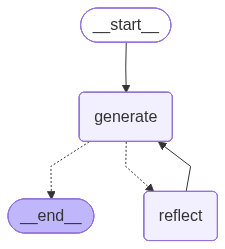

In [17]:
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
graph

In [18]:
config = {"configurable": {"thread_id": "1"}}

In [19]:
for event in graph.stream(
    {
        "messages": [
            HumanMessage(
                content="이별에 대한 가사를 작성해주세요."
            )
        ],
    },
    config,
):
    print(event)
    print("---")

{'generate': {'messages': [AIMessage(content='1.\n문을 닫던 네 뒷모습에  \n늦은 저녁이 조용히 앉아 있었어  \n잡지 못한 한마디가 목에 걸린 채  \n나는 끝내 웃는 척만 했어  \n우리의 계절은 그렇게 식어 갔어  \n\n2.\n함께 걷던 골목 끝 가로등 아래  \n아직도 네 그림자가 남아 있는 것 같아  \n스쳐 가는 바람마저 네 이름 같아서  \n괜히 몇 번이나 뒤를 돌아봤어  \n없다는 걸 알면서도 또 찾게 돼  \n\n3.\n네가 두고 간 작은 습관들 사이로  \n텅 빈 하루가 더 크게 울려 퍼져  \n마시다 식어 버린 커피 한 잔처럼  \n우리 사랑도 천천히 식어 갔나 봐  \n이제는 되돌릴 수 없다는 걸 알아  \n\n4.\n밤이 깊을수록 더 선명해지는 건  \n미워했던 순간보다 따뜻했던 기억들  \n그래서 더 아파, 그래서 더 서러워  \n잊으려 할수록 더 짙어지는 얼굴  \n이별은 왜 늘 사랑 뒤에 오는 걸까  \n\n5.\n언젠가 이 슬픔도 무뎌지겠지만  \n오늘은 아직 네가 전부였던 나야  \n흐르지 못한 눈물 끝에 서서  \n잘 가라는 말조차 늦게 배워 가  \n사랑했던 만큼 오래 아플 것 같아', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 332, 'prompt_tokens': 182, 'total_tokens': 514, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.

In [20]:
state = graph.get_state(config)

In [21]:
ChatPromptTemplate.from_messages(state.values["messages"]).pretty_print()

================================ Human Message =================================

이별에 대한 가사를 작성해주세요.

================================== Ai Message ==================================

1.
문을 닫던 네 뒷모습에  
늦은 저녁이 조용히 앉아 있었어  
잡지 못한 한마디가 목에 걸린 채  
나는 끝내 웃는 척만 했어  
우리의 계절은 그렇게 식어 갔어  

2.
함께 걷던 골목 끝 가로등 아래  
아직도 네 그림자가 남아 있는 것 같아  
스쳐 가는 바람마저 네 이름 같아서  
괜히 몇 번이나 뒤를 돌아봤어  
없다는 걸 알면서도 또 찾게 돼  

3.
네가 두고 간 작은 습관들 사이로  
텅 빈 하루가 더 크게 울려 퍼져  
마시다 식어 버린 커피 한 잔처럼  
우리 사랑도 천천히 식어 갔나 봐  
이제는 되돌릴 수 없다는 걸 알아  

4.
밤이 깊을수록 더 선명해지는 건  
미워했던 순간보다 따뜻했던 기억들  
그래서 더 아파, 그래서 더 서러워  
잊으려 할수록 더 짙어지는 얼굴  
이별은 왜 늘 사랑 뒤에 오는 걸까  

5.
언젠가 이 슬픔도 무뎌지겠지만  
오늘은 아직 네가 전부였던 나야  
흐르지 못한 눈물 끝에 서서  
잘 가라는 말조차 늦게 배워 가  
사랑했던 만큼 오래 아플 것 같아

================================ Human Message =================================

1. 잘된 점  
- 이별의 정서를 무난하고 안정적으로 담아냈습니다.  
- “문을 닫던 네 뒷모습”, “함께 걷던 골목 끝 가로등”, “마시다 식어 버린 커피” 같은 이미지가 익숙하지만 감정 전달에는 효과적입니다.  
- 전체적으로 슬픔, 미련, 체념으로 이어지는 흐름이 자연스럽습니다.  
- 문체가 과하게 꾸미지 않아 대중적인 발라드 가사로 쓰기 좋은 톤입니다.  

2

#**2. Reflextion 구현**
“Reflexion: Language Agents with Verbal Reinforcement Learning”은, 2023년 3월 20일 최초 제출, 2023년 10월 10일 v4로 개정된 논문입니다. 저자는 Noah Shinn 외 5명이고, 핵심 내용은 언어 에이전트가 스스로 언어적 피드백(반성문)을 생성·메모리에 저장해 다음 시도에 반영함으로써 성능을 높이는 프레임워크를 제안했다는 점입니다. HumanEval 등에서 유의미한 향상을 보고합니다.

<img src ='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fdzon1Q%2FbtsQxdO7zsM%2FAAAAAAAAAAAAAAAAAAAAAIv8GnJo2Z7lQar4RlJWoaap2PH03wadiph8ot4leqkE%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3DYLvIQazd8nfTlqgPYHLcJHzHcpY%253D'>

- Actor (LM): 실제 행동(답안 작성, 코드 생성 등)을 내는 언어모델입니다.
- Evaluator (LM): Actor가 낸 결과를 내부적으로 평가합니다(정확성·형식·테스트 통과 여부 판단 등).
- Self-reflection (LM): 평가 결과를 바탕으로 “다음에는 이렇게 고치자” 같은 반성문(Reflective text)을 만들어 냅니다.
- Trajectory (short-term memory): 이번 시도에서의 행동/관찰 기록(a₀, o₀, …)을 담는 단기 메모리입니다.
- Experience (long-term memory): 누적된 반성문을 쌓아두는 장기 메모리(mem)입니다. 이후 시도에서 프롬프트에 이 기억을 넣어 같은 실수를 반복하지 않게 합니다.
- Environment: 외부에서 관찰/보상(예: 유닛 테스트의 통과/실패, 웹툴의 응답 등)을 제공합니다. 외부 피드백이 있으면 Evaluator의 판단과 함께 사용됩니다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fmii1M%2FbtsQzJFXs6L%2FAAAAAAAAAAAAAAAAAAAAABlDou97baB3Ry75PiiSdFP4Aml0fM58iNNa5PCw8tAm%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3DOKARG8790LTTUc0w9eiUkPnOHF4%253D'>

In [22]:
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("TAVILY_API_KEY")

TAVILY_API_KEY: ··········


In [23]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-5.4-2026-03-05")

In [24]:
!pip install langchain-tavily


In [25]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=5)

###**1. 필요한 데이터 클래스 정의**

In [26]:
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from pydantic import BaseModel, Field

In [27]:
class Reflection(BaseModel):
    missing: str = Field(description="누락되거나 부족한 부분에 대한 비평")
    superfluous: str = Field(description="불필요한 부분에 대한 비평")

In [28]:
class AnswerQuestion(BaseModel):
    answer: str = Field(description="질문에 대한 10문장 이내의 자세한 답변")
    search_queries: list[str] = Field(description="현재 답변에 대한 비평을 해결하기 위한 추가 조사를 위한 1~3개의 웹 검색 쿼리")
    reflection: Reflection = Field(description="답변에 대한 자기반성 내용")

In [29]:
class Responder:
    def __init__(self, runnable):
        self.runnable = runnable

    def respond(self, state: dict):
        response = self.runnable.invoke(
            {"messages": state["messages"]}
        )
        return{"messages": response}

###**2. 초기 답변기 만들기**

In [30]:
actor_prompt_template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """당신은 전문 연구자입니다.

            1. {first_instruction}
            2. <Reflect> 생성한 답변을 다시 되돌아보고 개선할 수 있도록 비판하세요.
            3. <Recommend search queries> 답변의 질을 높이기 위해 추가적으로 조사해야 할 정보에 대한 웹 검색 쿼리를 추천하세요.""",
        ),
        MessagesPlaceholder(variable_name = "messages"),
        (
            "user",
            "\n\n<Reflect> 사용자 원래 질문과 지금까지의 행동을 되돌아보세요."
        ),
    ]
)

In [31]:
# 프롬프트를 만듦
# 프롬프트를 LLM에 넣음
# LLM은 AnswerQuestion 구조에 맞는 구조를 반환
initial_answer_chain = actor_prompt_template.partial(
    first_instruction="질문에 대한 10문장 이내의 자세한 답변을 제공해주세요.", # 초기 답변
) | llm.bind_tools(tools=[AnswerQuestion], tool_choice="any")

In [32]:
Llm_with_tool = llm.bind_tools(tools = [AnswerQuestion], tool_choice = 'any')
response = Llm_with_tool.invoke([HumanMessage(content = "AI Agent가 무엇인가요?")])
response

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 362, 'prompt_tokens': 218, 'total_tokens': 580, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DNGSL2fIbU67tg52GGAWu7JeYIxkj', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d24b2-8977-75f2-94c1-7d52f9b63a46-0', tool_calls=[{'name': 'AnswerQuestion', 'args': {'answer': 'AI Agent는 주어진 목표를 달성하기 위해 주변 정보를 인식하고, 판단하며, 필요한 행동을 스스로 수행하는 인공지능 시스템입니다. 단순히 질문에 답하는 챗봇과 달리, AI Agent는 계획을 세우고 여러 단계를 거쳐 작업을 실행할 수 있습니다. 예를 들어 사용자의 요청을 이해한 뒤, 필요한 정보를 찾고, 도구를 사용하고, 결과를 정리해 전달하는 식으로 동작합니다. 이런 점에서 AI Agent는 ‘지시를 받으면 행동까지 이어가는 AI’라고 볼 수 있습니다. 대표적인 예로 일정 예약, 이메일 분류, 고객 지원 자동화, 데이터 분석 보조

In [41]:
response.tool_calls[0]['args']

{'answer': 'AI Agent는 주어진 목표를 달성하기 위해 주변 정보를 인식하고, 판단하며, 필요한 행동을 스스로 수행하는 인공지능 시스템입니다. 단순히 질문에 답하는 챗봇과 달리, AI Agent는 계획을 세우고 여러 단계를 거쳐 작업을 실행할 수 있습니다. 예를 들어 사용자의 요청을 이해한 뒤, 필요한 정보를 찾고, 도구를 사용하고, 결과를 정리해 전달하는 식으로 동작합니다. 이런 점에서 AI Agent는 ‘지시를 받으면 행동까지 이어가는 AI’라고 볼 수 있습니다. 대표적인 예로 일정 예약, 이메일 분류, 고객 지원 자동화, 데이터 분석 보조 등이 있습니다. 보통 AI Agent는 언어모델, 메모리, 외부 도구 사용 능력, 그리고 목표 관리 기능으로 구성됩니다. 또 상황 변화에 따라 다음 행동을 조정할 수 있어 비교적 유연하게 문제를 해결합니다. 다만 항상 완벽한 것은 아니며, 잘못된 판단이나 부정확한 정보 처리 가능성도 있어 검증과 통제가 중요합니다. 즉, AI Agent는 ‘생각하는 AI’를 넘어 ‘행동하는 AI’에 더 가까운 개념입니다.',
 'search_queries': ['AI Agent 개념 설명',
  'AI agent vs chatbot 차이',
  'AI 에이전트 구성 요소'],
 'reflection': {'missing': '사용자 수준에 맞춘 더 쉬운 비유나 실제 사례를 1~2개 더 넣으면 이해가 쉬워질 수 있다.',
  'superfluous': '짧은 정의를 원하는 사용자에게는 구성 요소 설명이 약간 많을 수 있다.'}}

In [34]:
first_responder = Responder(runnable = initial_answer_chain)

In [35]:
example_question = "AI Agent가 무엇인가요?"
initial = first_responder.respond(
    {"messages": [HumanMessage(content=example_question)]}
)

In [36]:
initial

{'messages': AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 568, 'prompt_tokens': 335, 'total_tokens': 903, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DNGSSTbhVDcFCsBYj9bs75txr4HV4', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d24b2-a278-7100-af7c-5e2ec7553e08-0', tool_calls=[{'name': 'AnswerQuestion', 'args': {'answer': 'AI Agent는 목표를 달성하기 위해 환경을 인식하고, 정보를 해석하며, 스스로 행동을 선택하는 인공지능 시스템입니다. 단순한 챗봇이 주어진 질문에만 응답하는 것과 달리, AI Agent는 계획을 세우고 여러 단계의 작업을 수행하며 필요하면 외부 도구나 데이터를 활용할 수 있습니다. 예를 들어 일정 예약, 이메일 분류, 웹 검색, 코드 실행, 보고서 작성 같은 일을 사용자의 지시에 따라 연속적으로 처리할 수 있습니다. 핵심 요소는 보통 목표(goal), 관찰(observation), 추론(reasoning), 

In [37]:
initial["messages"].tool_calls[0]["args"]

{'answer': 'AI Agent는 목표를 달성하기 위해 환경을 인식하고, 정보를 해석하며, 스스로 행동을 선택하는 인공지능 시스템입니다. 단순한 챗봇이 주어진 질문에만 응답하는 것과 달리, AI Agent는 계획을 세우고 여러 단계의 작업을 수행하며 필요하면 외부 도구나 데이터를 활용할 수 있습니다. 예를 들어 일정 예약, 이메일 분류, 웹 검색, 코드 실행, 보고서 작성 같은 일을 사용자의 지시에 따라 연속적으로 처리할 수 있습니다. 핵심 요소는 보통 목표(goal), 관찰(observation), 추론(reasoning), 행동(action), 그리고 때로는 기억(memory)입니다. 최근의 AI Agent는 대형언어모델을 기반으로 하여 자연어 이해와 생성 능력을 활용하면서도, API 호출이나 소프트웨어 제어 같은 실제 작업 수행 능력을 결합하는 경우가 많습니다. 다만 완전한 자율성을 가진다고 보기보다는, 정해진 권한과 규칙 안에서 반자율적으로 작동하는 경우가 대부분입니다. 장점은 반복 업무 자동화, 생산성 향상, 복잡한 작업의 단계별 처리에 있지만, 단점으로는 오판, 잘못된 도구 사용, 보안 문제, 책임 소재의 불명확성이 있습니다. 따라서 AI Agent를 설계하거나 사용할 때는 목표 정의, 권한 제한, 인간의 검토 절차, 로그 기록 같은 안전장치가 중요합니다. 사용자의 원래 질문은 개념 설명을 요청하는 것이었고, 지금까지의 상호작용에서는 추가 맥락이나 구체적 사용 사례가 제시되지 않았으므로 기본 개념과 특징 중심으로 답하는 것이 가장 적절합니다.',
 'search_queries': ['AI agent definition vs chatbot difference',
  'LLM-based AI agent architecture goals memory tools',
  'AI agent safety risks human-in-the-loop governance'],
 'reflection': {'missing': "구체적인 산업별 사례나 전통적 소프트

In [38]:
example_question = "AI Agent가 무엇인가요?"
initial = first_responder.respond(
    {"messages": [HumanMessage(content=example_question)]}
)

In [39]:
initial

{'messages': AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 530, 'prompt_tokens': 335, 'total_tokens': 865, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DNGWYwSog0ILSlSqAvZfIQAvNgPPw', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d24b6-8243-73b0-b233-a5058e8ed25a-0', tool_calls=[{'name': 'AnswerQuestion', 'args': {'answer': 'AI Agent는 목표를 달성하기 위해 환경을 인식하고, 정보를 해석하며, 스스로 행동을 선택·실행하는 인공지능 시스템입니다. 일반적인 생성형 AI가 질문에 답하는 데 머무는 경우가 많다면, AI Agent는 계획 수립, 도구 사용, 작업 실행, 결과 평가까지 더 능동적으로 수행할 수 있습니다. 예를 들어 이메일 정리, 일정 예약, 데이터 검색, 보고서 초안 작성 같은 여러 단계의 업무를 연속적으로 처리할 수 있습니다. 핵심 구성 요소로는 목표(goal), 입력 인식(perception), 추론(reasoning

###**3. 수정 단계(Revision)**

In [42]:
class ReviseAnswer(AnswerQuestion):
    """Revise your original answer to your question. Provide an answer, reflection,

    cite your reflection with references, and finally
    add search queries to improve the answer."""

    references: list[str] = Field(description="업데이트된 답변에 사용된 인용 출처")

In [43]:
# 수정 지시문
revise_instructions = """이전 답변을 새로운 정보를 바탕으로 수정하세요.
- 이전 비평 내용을 활용해 중요한 정보를 추가해야 합니다.
  - 수정된 답변에는 반드시 숫자로 된 인용 표시를 포함하여 검증 가능하도록 해야 합니다.
  - 답변 하단에 "참고문헌" 섹션을 추가하세요 (이 부분은 단어 수 제한에 포함되지 않습니다). 형식은 다음과 같습니다:
    - [1] https://example.com
    - [2] https://example.com

- 이전 비평 내용을 바탕으로 불필요한 정보를 제거하고, 최종 답변은 반드시 200자를 넘지 않도록 하세요.
"""


revision_chain = actor_prompt_template.partial(
    first_instruction=revise_instructions,
) | llm.bind_tools(tools=[ReviseAnswer], tool_choice="any")


revisor = Responder(runnable=revision_chain)

In [46]:
import json

revised = revisor.respond(
    {
        "messages": [
            HumanMessage(content=example_question),
            initial["messages"],
            ToolMessage(
                tool_call_id=initial['messages'].tool_calls[0]['id'],
                content=json.dumps(
                    tavily_tool.invoke(
                        {
                            "query": initial["messages"].tool_calls[0]["args"]['search_queries'][0]
                        }
                    )
                ),
            ),
        ]
    }
)

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FnMKU1%2FbtsQwRziUZl%2FAAAAAAAAAAAAAAAAAAAAAASlhE2QFrMfwp2mVpfbJqW1PV9_JrnKxfrPSLouN6QH%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3DTy2ZJklv8PUca0y%252FmQR9PTDcOP4%253D'>

In [47]:
revised["messages"]

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 260, 'prompt_tokens': 2144, 'total_tokens': 2404, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DNHRI9VbwAOavSRkgEN2IuVRjzQFB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d24ec-28ce-7ec2-9fce-1dfc2e45edeb-0', tool_calls=[{'name': 'ReviseAnswer', 'args': {'answer': '사용자는 AI Agent의 정의를 물었고, 이어 답변이 원질문에 맞았는지 성찰을 요청했습니다. 핵심은 ‘정의’였으나 이전 답변은 메타 설명이 다소 길었습니다. AI Agent는 목표 달성을 위해 인식·추론·행동하는 시스템이며, 챗봇보다 도구 사용과 작업 수행 자율성이 큽니다[1][2].', 'search_queries': ['NIST AI agent definition', 'IBM AI agent overview tool use autonomy', 'chatbot vs AI agent autonomy definition'], 'refl

In [48]:
revised["messages"].tool_calls

[{'name': 'ReviseAnswer',
  'args': {'answer': '사용자는 AI Agent의 정의를 물었고, 이어 답변이 원질문에 맞았는지 성찰을 요청했습니다. 핵심은 ‘정의’였으나 이전 답변은 메타 설명이 다소 길었습니다. AI Agent는 목표 달성을 위해 인식·추론·행동하는 시스템이며, 챗봇보다 도구 사용과 작업 수행 자율성이 큽니다[1][2].',
   'search_queries': ['NIST AI agent definition',
    'IBM AI agent overview tool use autonomy',
    'chatbot vs AI agent autonomy definition'],
   'reflection': {'missing': '원질문에 대해 더 짧고 직접적인 정의를 먼저 제시했어야 했습니다. 이후 차이점은 보충으로 두는 편이 적절했습니다[1].',
    'superfluous': '이전 답변의 대화 메타분석은 사용자의 후속 요청 전에는 불필요하게 길었습니다. 입문 질문에는 간결성이 더 중요했습니다[2].'},
   'references': ['https://www.ibm.com/think/topics/ai-agents',
    'https://www.digitalocean.com/resources/articles/ai-agent-vs-ai-chatbot']},
  'id': 'call_78EtZ1JE1kowdZBUjLr3UPou',
  'type': 'tool_call'}]

###**4. 웹검색을 위한 툴 노드 생성**

In [49]:
# batch: 여러 개의 검색 요청을 한 번에 실행하는 함수
tavily_tool.batch(
    [
        # AIMessage 객체 -> 모델이 호출한 첫번째 tool(AnswerQuestion 결과) -> 툴에 전달된 실제 데이터 -> 모델이 추천한 검색어 중 첫번째만 선택
        {"query": initial["messages"].tool_calls[0]["args"]['search_queries'][0]}
    ]
)

[{'query': 'AI agent definition vs chatbot difference',
  'response_time': 1.64,
  'follow_up_questions': None,
  'answer': None,
  'images': [],
  'results': [{'url': 'https://www.digitalocean.com/resources/articles/ai-agent-vs-ai-chatbot',
    'title': 'AI Agent vs AI Chatbot: Key Differences Explained - DigitalOcean',
    'content': 'An AI agent is a more advanced artificial intelligence system capable of performing complex tasks and making decisions with minimal human guidance.',
    'score': 0.9999577,
    'raw_content': None},
   {'url': 'https://www.qualified.com/plus/articles/chatbots-vs-ai-agents-whats-the-difference',
    'title': "Chatbots vs. AI agents: What's the difference? - Qualified",
    'content': 'While a chatbot gives you a limited interaction based on what it’s been programmed to recognize, an AI agent taps into customer data, CRM systems, and your broader tech stack to generate leads, qualify buyers, and move pipeline forward—all without human intervention. While

In [50]:
from langchain_core.tools import StructuredTool
from langgraph.prebuilt import ToolNode

In [51]:
# [{"query": AI agent definition"}, {"query": AI agent examples"}]
def run_queries(search_queries: list[str], **kwargs):
    """Run the generated queries."""
    return tavily_tool.batch([{"query": query} for query in search_queries])

In [52]:
tool_node = ToolNode(
    [
        StructuredTool.from_function(run_queries, name=AnswerQuestion.__name__),
        StructuredTool.from_function(run_queries, name=ReviseAnswer.__name__),
    ]
)

###**5. 그래프 생성하기**

In [53]:
from langgraph.graph import END, StateGraph, START
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict

In [54]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [55]:
MAX_ITERATIONS = 5
graph_builder = StateGraph(State)
graph_builder.add_node("draft", first_responder.respond)
graph_builder.add_node("execute_tools", tool_node) # 웹 검색 진행
graph_builder.add_node("revise", revisor.respond)

graph_builder.add_edge("draft", "execute_tools")
graph_builder.add_edge("execute_tools", "revise")

In [56]:
def _get_num_iterations(state: list):
    i = 0
    # AI -> Tool -> AI -> Human 순서로 만듦. Human 또는 system.이면 중단.
    for m in state[::-1]:
        if m.type not in {"tool", "ai"}:
            break
        i += 1
    return i

In [57]:
def event_loop(state: list):
    num_iterations = _get_num_iterations(state["messages"])
    if num_iterations > MAX_ITERATIONS:
        return END
    return "execute_tools"

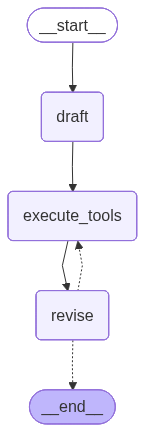

In [58]:
graph_builder.add_conditional_edges("revise", event_loop, ["execute_tools", END])
graph_builder.add_edge(START, "draft")
graph = graph_builder.compile()
graph

In [59]:
events = graph.stream(
    {"messages": [HumanMessage(content="AI Agent가 무엇인가요?")]},
    stream_mode="values",
)
for i, step in enumerate(events):
    print(f"Step {i}")
    step["messages"][-1].pretty_print()

Step 0
================================ Human Message =================================

AI Agent가 무엇인가요?
Step 1
================================== Ai Message ==================================
Tool Calls:
  AnswerQuestion (call_IHOUzOcuwA01ttJ26wiKveub)
 Call ID: call_IHOUzOcuwA01ttJ26wiKveub
  Args:
    answer: AI Agent는 주어진 목표를 달성하기 위해 환경을 인식하고, 정보를 수집·추론하며, 스스로 행동을 선택하는 인공지능 시스템입니다. 단순히 질문에 답하는 챗봇과 달리, AI Agent는 계획을 세우고 여러 단계의 작업을 수행하며 필요하면 도구나 외부 시스템도 사용할 수 있습니다. 예를 들어 일정 예약, 문서 요약, 데이터 검색, 이메일 작성처럼 목표 지향적인 업무를 연속적으로 처리할 수 있습니다. 일반적으로 AI Agent는 입력 이해, 상태 판단, 행동 계획, 실행, 결과 평가의 흐름으로 작동합니다. 이때 메모리 기능이 있으면 이전 대화나 작업 맥락을 기억해 더 일관된 결정을 내릴 수 있습니다. 또한 API, 데이터베이스, 검색엔진, 소프트웨어 도구와 연결되면 실제 업무를 자동화하는 능력이 크게 높아집니다. 다만 잘못된 정보에 기반해 행동하거나 예상치 못한 결정을 내릴 수 있어 검증, 권한 관리, 안전장치가 중요합니다. 최근의 AI Agent는 대규모 언어모델을 중심으로 발전하고 있으며, ‘생성’뿐 아니라 ‘행동’까지 수행하는 방향으로 확장되고 있습니다. 즉, AI Agent는 생각만 하는 AI가 아니라 목표를 향해 스스로 판단하고 실행하는 디지털 작업자라고 볼 수 있습니다.
    search_queries: ['AI agent definition vs chatbot', 'LLM-based AI age